In [ ]:
#id first_training
#caption Results from the first training
# CLICK ME
from fastai.vision.all import *
path = untar_data(URLs.PETS)/'images'

def is_cat(x): return x[0].isupper()
dls = ImageDataLoaders.from_name_func(
    path, get_image_files(path), valid_pct=0.2, seed=42,
    label_func=is_cat, item_tfms=Resize(224))

learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1)

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:18&lt;00:00]</div>

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 135MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,0.177399,0.017868,0.005413,00:40


epoch,train_loss,valid_loss,error_rate,time
0,0.063818,0.014325,0.004736,00:43


In [ ]:
image_cat = get_image_files(path)[0]

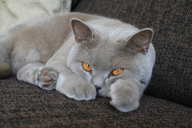

In [ ]:
from fastai.vision.all import *

path = untar_data(URLs.PETS)/'images'

image_cat = get_image_files(path)[5]  # pick one image

img = PILImage.create(image_cat)
img.to_thumb(192)

In [ ]:
img = PILImage.create('/content/images.jpg')
is_cat,_,probs = learn.predict(img)
print(f"Is this a cat?: {is_cat}.")
print(f"Probability it's a cat: {probs[1].item():.6f}")

FileNotFoundError: [Errno 2] No such file or directory: '/content/images.jpg'

In [ ]:
path = untar_data(URLs.CAMVID_TINY)
dls = SegmentationDataLoaders.from_label_func(
    path, bs=8, fnames = get_image_files(path/"images"),
    label_func = lambda o: path/'labels'/f'{o.stem}_P{o.suffix}',
    codes = np.loadtxt(path/'codes.txt', dtype=str)
)

learn = unet_learner(dls, resnet34)
learn.fine_tune(8)

<div><progress max="2314212" value="2318336"></progress> 100.18% [2318336/2314212 00:00&lt;00:00]</div>

epoch,train_loss,valid_loss,time
0,2.950907,2.141467,00:01


epoch,train_loss,valid_loss,time
0,1.659794,1.400809,00:01
1,1.505529,1.262836,00:01
2,1.376837,1.097295,00:01
3,1.254795,0.913203,00:02
4,1.132932,0.816195,00:01
5,1.030775,0.741029,00:01
6,0.947458,0.707828,00:01
7,0.878457,0.699288,00:01


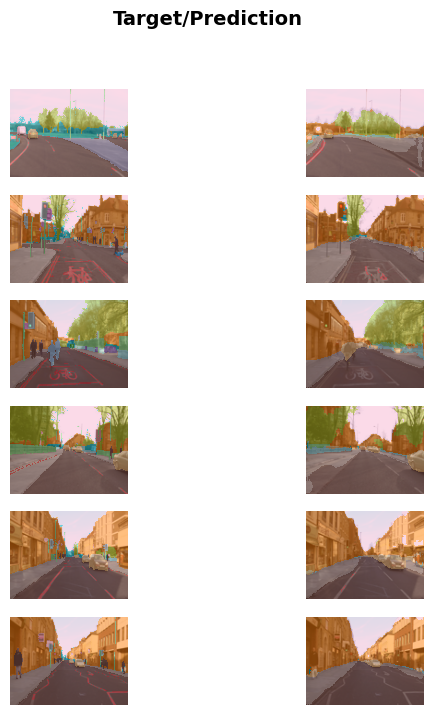

In [ ]:
learn.show_results(max_n=6, figsize=(7,8))

In [ ]:
from fastai.text.all import *

dls = TextDataLoaders.from_folder(untar_data(URLs.IMDB), valid='test')
learn = text_classifier_learner(dls, AWD_LSTM, drop_mult=0.5, metrics=accuracy)
learn.fine_tune(4, 1e-2)

<div><progress max="144440600" value="144441344"></progress> 100.00% [144441344/144440600 00:03&lt;00:00]</div>

<div><progress max="105067061" value="105070592"></progress> 100.00% [105070592/105067061 00:02&lt;00:00]</div>

epoch,train_loss,valid_loss,accuracy,time
0,0.471414,0.396257,0.820880,03:37


epoch,train_loss,valid_loss,accuracy,time
0,0.315102,0.257751,0.898440,07:38


epoch,train_loss,valid_loss,accuracy,time
0,0.315102,0.257751,0.898440,07:38
